<a href="https://colab.research.google.com/github/K-lin99/COMP472-AI-Group-Project-/blob/mobilenetv2-hyperparameter-tuning/mobilenet_v2_brain_tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MobileNet V2

## 1. Setup

In [1]:
!pip install torchmetrics grad-cam monai --quiet
!pip install optuna --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 108.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 31.4 MB/s eta 0:00:00


In [2]:
import copy, time, random, warnings, shutil, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchmetrics import Accuracy, Precision, Recall, F1Score
from sklearn.metrics import classification_report, confusion_matrix
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from google.colab import drive

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

mount_path = '/content/drive'
if os.path.exists(mount_path) and not os.path.ismount(mount_path):
    print(f'Removing local non-mount directory: {mount_path}')
    shutil.rmtree(mount_path)

# Mount Google Drive
drive.mount(mount_path, force_remount=True)

OUTPUT_DIR = Path('/content/drive/MyDrive/COMP472/outputs/mobilenet_v2')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda
Mounted at /content/drive


## 2. Hyperparameters

In [3]:
BATCH_SIZE    = 32
NUM_EPOCHS    = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
IMG_SIZE      = 224

## 3. Data (To fill)

Replace each `None` with the DataLoader.  
Images must be tensors of shape `(batch, 3, 224, 224)`, normalized with:
```
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
```
(This can be changed if needed)

### 3.1 Load Datasets

In [4]:
from torch.utils.data import DataLoader

preprocessed_dir = '/content/drive/MyDrive/brain_mri_preprocessed'

# ── Dataset 1 : 3,264 images - 4 classes ──────────────────────────
train_data_ds1 = torch.load(f'{preprocessed_dir}/dataset1_train.pt', weights_only=False)
val_data_ds1   = torch.load(f'{preprocessed_dir}/dataset1_val.pt', weights_only=False)
test_data_ds1  = torch.load(f'{preprocessed_dir}/dataset1_test.pt', weights_only=False)

train_images_ds1 = train_data_ds1['images']
train_labels_ds1 = train_data_ds1['labels']
val_images_ds1   = val_data_ds1['images']
val_labels_ds1   = val_data_ds1['labels']
test_images_ds1  = test_data_ds1['images']
test_labels_ds1  = test_data_ds1['labels']
class_names_ds1 = list(train_data_ds1['class_to_label'].keys())

# ── Dataset 2 : 7,023 images - 4 classes ──────────────────────────
train_data_ds2 = torch.load(f'{preprocessed_dir}/dataset2_train.pt', weights_only=False)
val_data_ds2   = torch.load(f'{preprocessed_dir}/dataset2_val.pt', weights_only=False)
test_data_ds2  = torch.load(f'{preprocessed_dir}/dataset2_test.pt', weights_only=False)

train_images_ds2 = train_data_ds2['images']
train_labels_ds2 = train_data_ds2['labels']
val_images_ds2   = val_data_ds2['images']
val_labels_ds2   = val_data_ds2['labels']
test_images_ds2  = test_data_ds2['images']
test_labels_ds2  = test_data_ds2['labels']

class_names_ds2 = list(train_data_ds1['class_to_label'].keys())

# ── Dataset 3 : 4,478 images - 44 classes ─────────────────────────
train_data_ds3 = torch.load(f'{preprocessed_dir}/dataset3_train.pt', weights_only=False)
val_data_ds3   = torch.load(f'{preprocessed_dir}/dataset3_val.pt', weights_only=False)
test_data_ds3  = torch.load(f'{preprocessed_dir}/dataset3_test.pt', weights_only=False)

train_images_ds3 = train_data_ds3['images']
train_labels_ds3 = train_data_ds3['labels']
val_images_ds3   = val_data_ds3['images']
val_labels_ds3   = val_data_ds3['labels']
test_images_ds3  = test_data_ds3['images']
test_labels_ds3  = test_data_ds3['labels']

class_names_ds3 = list(train_data_ds3['class_to_label'].keys())

### 3.2 Data Augmentation

In [5]:
# Monai imports

!python -c "import monai" || pip install -q "monai-weekly[ignite, tqdm]"

import logging
import numpy as np
import os
from pathlib import Path
import sys
import tempfile
import torch

from monai.apps import MedNISTDataset
from monai.config import print_config
from monai.engines import SupervisedTrainer
from monai.handlers import StatsHandler
from monai.inferers import SimpleInferer
from monai.networks import eval_mode
from monai.networks.nets import densenet121
from monai.transforms import (
    Compose,
    LoadImage,
    EnsureChannelFirst,
    Resize,
    NormalizeIntensity,
    RandFlipd,
    RandRotate,
    RandZoom,
    RandGaussianNoise,
    RandAdjustContrast,
    RandShiftIntensity,
    EnsureType,
)
from monai.data import ImageDataset


print_config()

# Define Augmentation class and transformation
class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

def get_train_transforms():
    return Compose([
        RandRotate(range_x=0.15, prob=0.5, keep_size=True),
        RandZoom(min_zoom=0.95, max_zoom=1.05, prob=0.3, keep_size=True),
        RandGaussianNoise(mean=0.0, std=0.01, prob=0.2),
        RandAdjustContrast(gamma=(0.9, 1.1), prob=0.2),
        RandShiftIntensity(offsets=0.05, prob=0.2),
    ])



# ── Dataset 1 : AugmentDataset  ──────────────────────────
train_dataset_ds1 = AugmentedDataset(train_images_ds1, train_labels_ds1, transform=get_train_transforms())
val_dataset_ds1   = AugmentedDataset(val_images_ds1,   val_labels_ds1,   transform=None)
test_dataset_ds1  = AugmentedDataset(test_images_ds1,  test_labels_ds1,  transform=None)

# ── Dataset 2 : AugmentDataset  ──────────────────────────

train_dataset_ds2 = AugmentedDataset(train_images_ds2, train_labels_ds2, transform=get_train_transforms())
val_dataset_ds2   = AugmentedDataset(val_images_ds2,   val_labels_ds2,   transform=None)
test_dataset_ds2  = AugmentedDataset(test_images_ds2,  test_labels_ds2,  transform=None)

# ── Dataset 3 : AugmentDataset  ──────────────────────────

train_dataset_ds3 = AugmentedDataset(train_images_ds3, train_labels_ds3, transform=get_train_transforms())
val_dataset_ds3   = AugmentedDataset(val_images_ds3,   val_labels_ds3,   transform=None)
test_dataset_ds3  = AugmentedDataset(test_images_ds3,  test_labels_ds3,  transform=None)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-05 14:50:29.015737: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775400629.038069    6336 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775400629.045356    6336 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775400629.064473    6336 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775400629.064511    6336 computation_placer.cc:1

### 3.3 Data Loaders

In [6]:
# ── Dataset 1 : assign Dataloaders ──────────────────────────
train_loader_ds1 = DataLoader(train_dataset_ds1, batch_size=BATCH_SIZE, shuffle=True)
val_loader_ds1   = DataLoader(val_dataset_ds1,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_ds1  = DataLoader(test_dataset_ds1,  batch_size=BATCH_SIZE, shuffle=False)

# ── Dataset 2 : assign Dataloaders ──────────────────────────
train_loader_ds2 = DataLoader(train_dataset_ds2, batch_size=BATCH_SIZE, shuffle=True)
val_loader_ds2   = DataLoader(val_dataset_ds2,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_ds2  = DataLoader(test_dataset_ds2,  batch_size=BATCH_SIZE, shuffle=False)

# ── Dataset 3 : assign Dataloaders ──────────────────────────
train_loader_ds3 = DataLoader(train_dataset_ds3, batch_size=BATCH_SIZE, shuffle=True)
val_loader_ds3   = DataLoader(val_dataset_ds3,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_ds3  = DataLoader(test_dataset_ds3,  batch_size=BATCH_SIZE, shuffle=False)

DATASETS = [
    {
        'name': 'Dataset 1 — Brain Tumor Classification (MRI)',
        'num_classes': 4, 'class_names': class_names_ds1,
        'train_loader': train_loader_ds1, 'val_loader': val_loader_ds1, 'test_loader': test_loader_ds1,
    },
    {
        'name': 'Dataset 2 — Brain Tumor MRI Dataset',
        'num_classes': 4, 'class_names': class_names_ds2,
        'train_loader': train_loader_ds2, 'val_loader': val_loader_ds2, 'test_loader': test_loader_ds2,
    },
    {
        'name': 'Dataset 3 — Brain Tumor MRI Images 44 Classes',
        'num_classes': 44, 'class_names': class_names_ds3,
        'train_loader': train_loader_ds3, 'val_loader': val_loader_ds3, 'test_loader': test_loader_ds3,
    },
]
print('DataLoaders re-initialized with TensorDatasets.')

DataLoaders re-initialized with TensorDatasets.


In [7]:
print(f"Dataset 1 Train size: {len(train_loader_ds1.dataset)} images")
print(f"Dataset 2 Train size: {len(train_loader_ds2.dataset)} images")
print(f"Dataset 3 Train size: {len(train_loader_ds3.dataset)} images")

Dataset 1 Train size: 2229 images
Dataset 2 Train size: 5036 images
Dataset 3 Train size: 11352 images


## 4. Model - MobileNet V2

In [8]:
def build_mobilenet_v2(num_classes: int) -> nn.Module:
    """
    Final classifier head is replaced to match num_classes (4 or 44).
    """
    model = models.mobilenet_v2(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model.to(DEVICE)

# Sanity check
_m = build_mobilenet_v2(4)
_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
print(f'Output shape    : {list(_m(_x).shape)}')
print(f'Trainable params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
del _m, _x

Output shape    : [2, 4]
Trainable params: 2,228,996


## 5. Training & Evaluation Functions

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, num_classes):
    model.train()
    loss_sum = 0.0
    acc_m = Accuracy(task='multiclass', num_classes=num_classes).to(DEVICE)
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        if imgs.shape[1] == 1: imgs = imgs.repeat(1, 3, 1, 1)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        acc_m.update(out.argmax(1), labels)
    return loss_sum / len(loader.dataset), acc_m.compute().item()

@torch.no_grad()
def evaluate(model, loader, criterion, num_classes):
    model.eval()
    loss_sum = 0.0
    acc_m = Accuracy(task='multiclass', num_classes=num_classes).to(DEVICE)
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        if imgs.shape[1] == 1: imgs = imgs.repeat(1, 3, 1, 1)
        out = model(imgs)
        loss_sum += criterion(out, labels).item() * imgs.size(0)
        acc_m.update(out.argmax(1), labels)
    return loss_sum / len(loader.dataset), acc_m.compute().item()

@torch.no_grad()
def full_evaluation(model, loader, num_classes, class_names):
    model.eval()
    all_preds, all_labels = [], []
    ms = {
        'acc':  Accuracy( task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
        'prec': Precision(task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
        'rec':  Recall(   task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
        'f1':   F1Score(  task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
    }
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        if imgs.shape[1] == 1: imgs = imgs.repeat(1, 3, 1, 1)
        preds = model(imgs).argmax(1)
        for m in ms.values(): m.update(preds, labels)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    results = {k: v.compute().item() for k, v in ms.items()}
    results.update({'all_preds': all_preds, 'all_labels': all_labels})
    print(f"  Accuracy : {results['acc']:.4f}")
    print(f"  Precision: {results['prec']:.4f}")
    print(f"  Recall   : {results['rec']:.4f}")
    print(f"  F1-Score : {results['f1']:.4f}")
    print(classification_report(all_labels, all_preds, target_names=(class_names if len(class_names) <= 20 else None), digits=4))
    return results

def train_model(model, cfg, save_path):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val, best_w = float('inf'), None
    nc = cfg['num_classes']
    for ep in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tl, ta = train_one_epoch(model, cfg['train_loader'], criterion, optimizer, nc)
        vl, va = evaluate(model, cfg['val_loader'], criterion, nc)
        scheduler.step(vl)
        for k, v in zip(history, [tl, vl, ta, va]): history[k].append(v)
        flag = ''
        if vl < best_val:
            best_val, best_w = vl, copy.deepcopy(model.state_dict())
            torch.save(best_w, save_path)
            flag = ' ✅'
        print(f'Ep [{ep:>2}/{NUM_EPOCHS}] Train {tl:.4f}/{ta:.4f} | Val {vl:.4f}/{va:.4f} | {time.time()-t0:.1f}s{flag}')
    model.load_state_dict(best_w)
    return model, history

print('Training & evaluation functions fixed for grayscale input.')

Training & evaluation functions fixed for grayscale input.


## 6. Visualization Functions

In [10]:
def plot_curves(history, name, save_path):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'MobileNet V2 — {name}', fontweight='bold')
    for ax, key, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
        ax.plot(epochs, history[f'train_{key}'], 'b-o', ms=4, label='Train')
        ax.plot(epochs, history[f'val_{key}'],   'r-o', ms=4, label='Val')
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)
        if key == 'acc': ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()

def plot_confusion_matrix(results, class_names, name, save_path):
    cm = confusion_matrix(results['all_labels'], results['all_preds'], normalize='true')
    n  = len(class_names)
    fig, ax = plt.subplots(figsize=(min(n*0.7+2, 20), min(n*0.6+2, 18)))
    sns.heatmap(cm, annot=(n<=15), fmt=('.2f' if n<=15 else ''), cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.xticks(rotation=45, ha='right', fontsize=(8 if n>15 else 10))
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()

def plot_grad_cam(model, loader, class_names, name, save_path, n=8):
    model.eval()
    cam = GradCAM(model=model, target_layers=[model.features[-1]])
    imgs, labels = next(iter(loader))
    imgs = imgs[:n].to(DEVICE)
    if imgs.shape[1] == 1: imgs = imgs.repeat(1, 3, 1, 1)
    with torch.no_grad():
        preds = model(imgs).argmax(1).cpu()
    mean, std = np.array([0.485,0.456,0.406]), np.array([0.229,0.224,0.225])
    fig, axes = plt.subplots(2, n//2, figsize=(n*2, 8))
    fig.suptitle(f'Grad-CAM — {name}', fontweight='bold')
    for i, ax in enumerate(axes.flatten()):
        gc = cam(input_tensor=imgs[i:i+1], targets=[ClassifierOutputTarget(preds[i].item())])[0]
        img_np = np.clip(std * imgs[i].cpu().numpy().transpose(1,2,0) + mean, 0, 1).astype(np.float32)
        ax.imshow(show_cam_on_image(img_np, gc, use_rgb=True))
        ax.set_title(f'True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}', color=('green' if preds[i]==labels[i] else 'red'), fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()

print('Visualization functions fixed for grayscale input.')

Visualization functions fixed for grayscale input.


## 7. Hyperparameter Tuning with Optuna

Before training across all datasets, we use Optuna to find the best `LEARNING_RATE` and `BATCH_SIZE` using Dataset 2 as a benchmark.

In [11]:
import optuna
from torch.utils.data import DataLoader

def objective(trial):
  #Suggest Hyperparameters
  lr = trial.suggest_float("learning_rate", 1e-4, 9e-4, log=True)
  batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

  cfg = DATASETS[1]

  # Re-initialize DataLoaders for this specific batch size
  train_loader = DataLoader(train_dataset_ds1, batch_size=batch_size, shuffle=True)
  val_loader   = DataLoader(val_dataset_ds1,   batch_size=batch_size, shuffle=False)

  model = build_mobilenet_v2(cfg["num_classes"])

  criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
  optimizer = optim.Adam(model.parameters(), lr=lr)

  tuning_epochs = 10
  best_val_acc = 0.0

  for epoch in range(tuning_epochs):
    train_one_epoch(model, train_loader, criterion, optimizer, cfg["num_classes"])
    _, val_acc = evaluate(model, val_loader, criterion, cfg["num_classes"])

    if val_acc > best_val_acc:
      best_val_acc = val_acc

    trial.report(val_acc, epoch)
    if trial.should_prune():
      raise optuna.exceptions.TrialPruned()

  return best_val_acc

study = optuna.create_study(direction="maximize")

try:
  study.optimize(objective, n_trials=10)
  print("\nOptimization complete")
  print("Best params: ", study.best_params)

  # Update global variables with best found values
  LEARNING_RATE = study.best_params['learning_rate']
  BATCH_SIZE = study.best_params['batch_size']
  print(f"Global variables updated: LEARNING_RATE={LEARNING_RATE}, BATCH_SIZE={BATCH_SIZE}")
except Exception as e:
  print(f"Optuna trial failed: {e}")

[I 2026-04-05 14:50:39,178] A new study created in memory with name: no-name-374bdfe5-828b-4898-8589-332cbe56e472
[I 2026-04-05 14:53:55,193] Trial 0 finished with value: 0.9197530746459961 and parameters: {'learning_rate': 0.0008231652995083823, 'batch_size': 16}. Best is trial 0 with value: 0.9197530746459961.
[I 2026-04-05 14:57:11,793] Trial 1 finished with value: 0.8796296119689941 and parameters: {'learning_rate': 0.0002470270120169841, 'batch_size': 16}. Best is trial 0 with value: 0.9197530746459961.
[I 2026-04-05 15:00:18,987] Trial 2 finished with value: 0.7438271641731262 and parameters: {'learning_rate': 0.0001362812119333843, 'batch_size': 64}. Best is trial 0 with value: 0.9197530746459961.
[I 2026-04-05 15:03:36,545] Trial 3 finished with value: 0.9012345671653748 and parameters: {'learning_rate': 0.0002906227863167907, 'batch_size': 16}. Best is trial 0 with value: 0.9197530746459961.
[I 2026-04-05 15:06:39,391] Trial 4 finished with value: 0.8703703880310059 and parame


Optimization complete
Best params:  {'learning_rate': 0.0008231652995083823, 'batch_size': 16}
Global variables updated: LEARNING_RATE=0.0008231652995083823, BATCH_SIZE=16


In [12]:
def refinement_objective(trial):
  # Define a neighborhood around the previously found best LR
  best_lr = study.best_params['learning_rate']
  lr = trial.suggest_float("learning_rate", best_lr * 0.5, best_lr * 2.0, log=True)

  cfg = DATASETS[1]
  model = build_mobilenet_v2(cfg['num_classes'])

  criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
  optimizer = optim.Adam(model.parameters(), lr=lr)

  tuning_epochs = 10
  best_acc = 0.0
  for epoch in range(tuning_epochs):
    train_one_epoch(model, cfg['train_loader'], criterion, optimizer, cfg['num_classes'])
    _, val_acc = evaluate(model, cfg['val_loader'], criterion, cfg['num_classes'])
    best_acc = max(best_acc, val_acc)

  return best_acc

# Create a new study for the refinement phase
refine_study = optuna.create_study(direction='maximize')
refine_study.optimize(refinement_objective, n_trials=5)

initial_best_acc = study.best_value
refined_best_acc = refine_study.best_value

print(f"Initial Best Accuracy: {initial_best_acc:.4f} (LR: {study.best_params['learning_rate']:.6f})")
print(f"Refined Best Accuracy: {refined_best_acc:.4f} (LR: {refine_study.best_params['learning_rate']:.6f})")

if refined_best_acc > initial_best_acc:
    print("Refinement improved accuracy. Updating LEARNING_RATE.")
    LEARNING_RATE = refine_study.best_params['learning_rate']
else:
    print("Refinement did not improve accuracy. Keeping original LEARNING_RATE.")
    LEARNING_RATE = study.best_params['learning_rate']

print(f"Final LEARNING_RATE set to: {LEARNING_RATE:.6f}")

[I 2026-04-05 15:09:52,033] A new study created in memory with name: no-name-776ee9e3-7144-42c5-af82-37c152406e33
[I 2026-04-05 15:16:43,481] Trial 0 finished with value: 0.956944465637207 and parameters: {'learning_rate': 0.0006469282278215026}. Best is trial 0 with value: 0.956944465637207.
[I 2026-04-05 15:23:36,199] Trial 1 finished with value: 0.9486111402511597 and parameters: {'learning_rate': 0.0010857007822097885}. Best is trial 0 with value: 0.956944465637207.
[I 2026-04-05 15:30:23,535] Trial 2 finished with value: 0.9319444298744202 and parameters: {'learning_rate': 0.0005948927996266548}. Best is trial 0 with value: 0.956944465637207.
[I 2026-04-05 15:37:16,824] Trial 3 finished with value: 0.9263888597488403 and parameters: {'learning_rate': 0.0012754141981627207}. Best is trial 0 with value: 0.956944465637207.
[I 2026-04-05 15:44:07,123] Trial 4 finished with value: 0.9597222208976746 and parameters: {'learning_rate': 0.0009439990833500013}. Best is trial 4 with value: 0

Initial Best Accuracy: 0.9198 (LR: 0.000823)
Refined Best Accuracy: 0.9597 (LR: 0.000944)
✅ Refinement improved accuracy. Updating LEARNING_RATE.
Final LEARNING_RATE set to: 0.000944


## 7. Train on All 3 Datasets


  Dataset 1/3: Dataset 1 — Brain Tumor Classification (MRI)
  Classes: 4
Ep [ 1/20] Train 1.1156/0.5164 | Val 2.5585/0.2870 | 19.3s ✅
Ep [ 2/20] Train 0.9319/0.6128 | Val 1.2037/0.5525 | 18.0s ✅
Ep [ 3/20] Train 0.8102/0.6721 | Val 0.8978/0.6512 | 18.4s ✅
Ep [ 4/20] Train 0.6983/0.7214 | Val 0.6583/0.7562 | 18.3s ✅
Ep [ 5/20] Train 0.6413/0.7510 | Val 0.6858/0.7469 | 18.5s
Ep [ 6/20] Train 0.5478/0.8022 | Val 0.5397/0.8148 | 18.6s ✅
Ep [ 7/20] Train 0.4888/0.8071 | Val 0.3214/0.8981 | 18.4s ✅
Ep [ 8/20] Train 0.4546/0.8295 | Val 0.4951/0.8025 | 18.2s
Ep [ 9/20] Train 0.3894/0.8578 | Val 0.4142/0.8488 | 18.3s
Ep [10/20] Train 0.3350/0.8748 | Val 0.2702/0.9012 | 17.9s ✅
Ep [11/20] Train 0.2850/0.8860 | Val 0.4677/0.8519 | 17.9s
Ep [12/20] Train 0.2932/0.8937 | Val 0.4007/0.8765 | 18.5s
Ep [13/20] Train 0.2494/0.9062 | Val 0.3524/0.8827 | 17.9s
Ep [14/20] Train 0.2142/0.9291 | Val 0.2004/0.9290 | 18.2s ✅
Ep [15/20] Train 0.2097/0.9228 | Val 0.2207/0.9198 | 18.2s
Ep [16/20] Train 0.1975/0

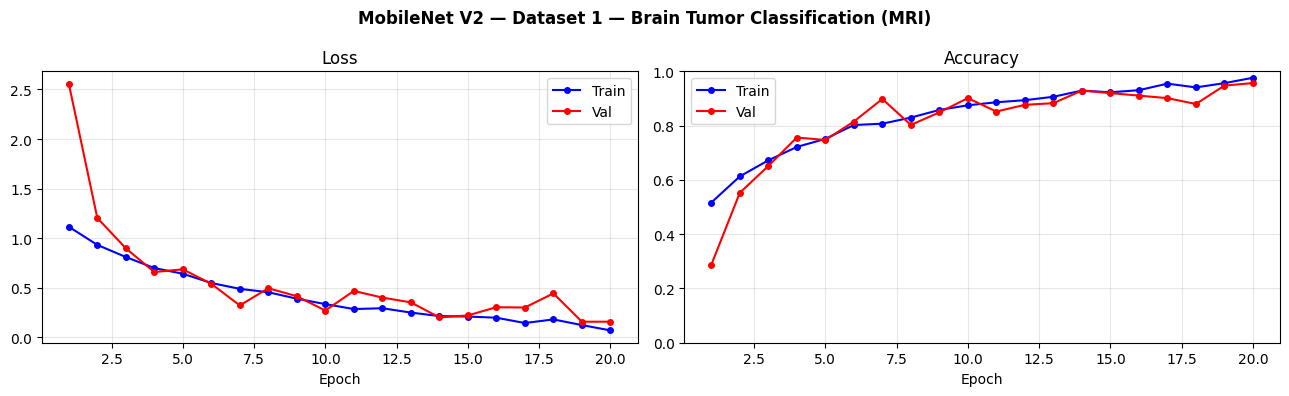

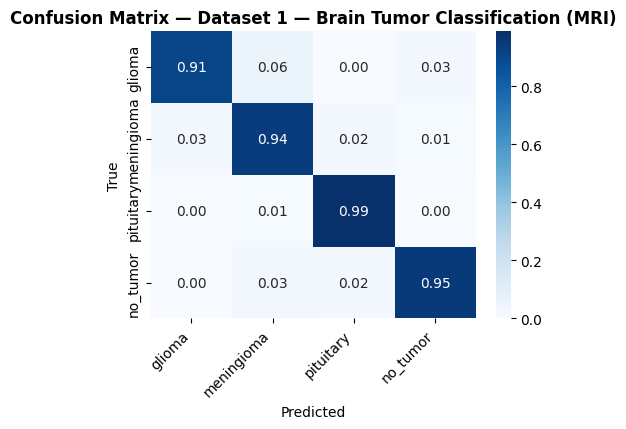

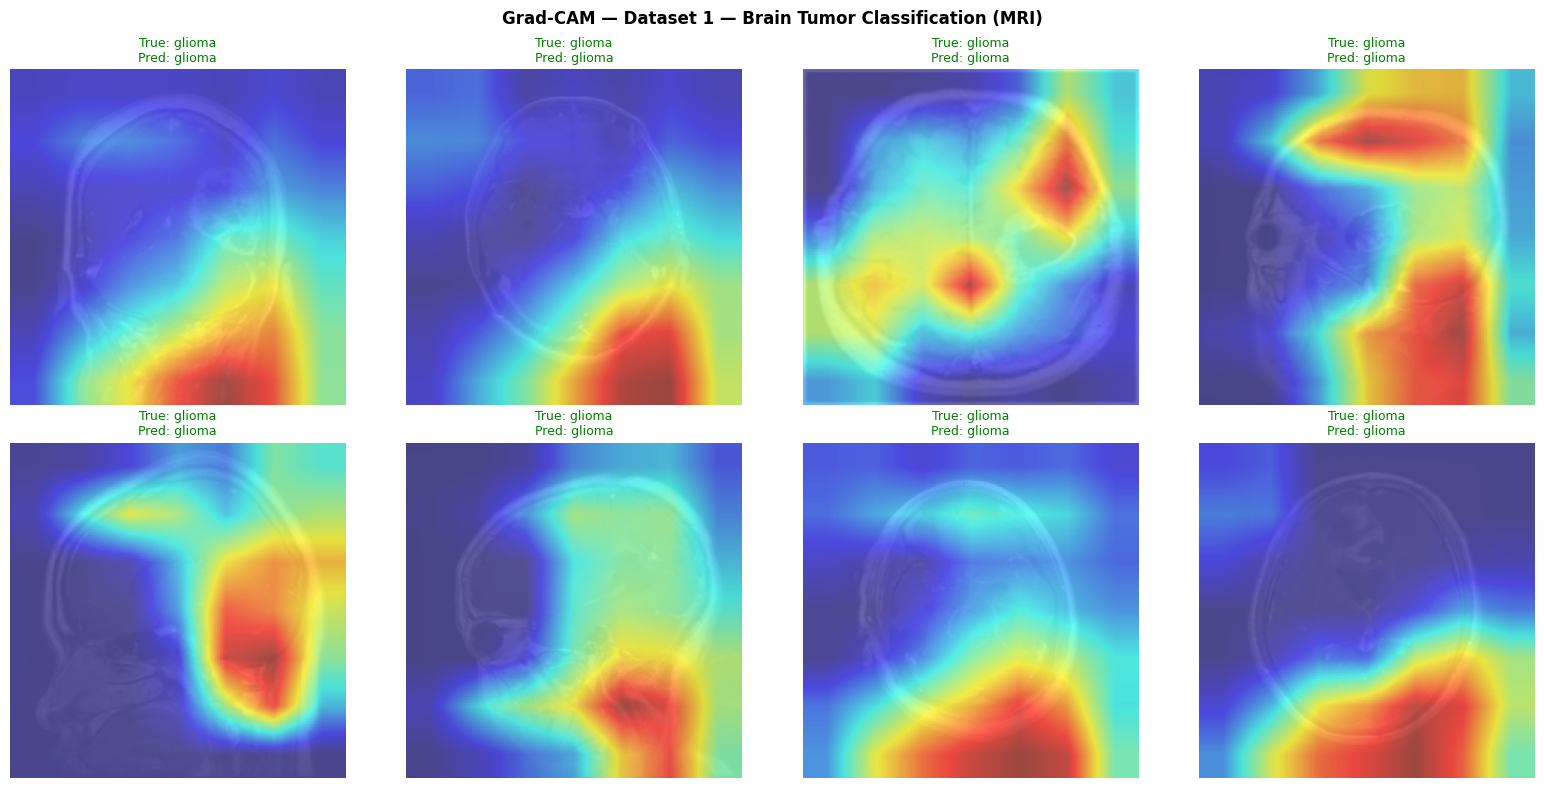


  Dataset 2/3: Dataset 2 — Brain Tumor MRI Dataset
  Classes: 4
Ep [ 1/20] Train 0.8842/0.6394 | Val 0.6888/0.7528 | 42.0s ✅
Ep [ 2/20] Train 0.6301/0.7508 | Val 0.5465/0.8167 | 41.4s ✅
Ep [ 3/20] Train 0.4876/0.8169 | Val 0.3834/0.8722 | 40.9s ✅
Ep [ 4/20] Train 0.4020/0.8527 | Val 0.3883/0.8611 | 41.1s
Ep [ 5/20] Train 0.3154/0.8898 | Val 0.2994/0.9000 | 41.4s ✅
Ep [ 6/20] Train 0.2774/0.8999 | Val 0.2922/0.9028 | 41.3s ✅
Ep [ 7/20] Train 0.2321/0.9190 | Val 0.2655/0.8986 | 41.1s ✅
Ep [ 8/20] Train 0.2016/0.9283 | Val 0.4345/0.8542 | 40.7s
Ep [ 9/20] Train 0.1944/0.9297 | Val 0.2680/0.9028 | 41.3s
Ep [10/20] Train 0.1658/0.9398 | Val 0.2246/0.9194 | 41.7s ✅
Ep [11/20] Train 0.1717/0.9371 | Val 0.1318/0.9542 | 41.2s ✅
Ep [12/20] Train 0.1481/0.9519 | Val 0.2005/0.9278 | 41.1s
Ep [13/20] Train 0.1327/0.9549 | Val 0.2934/0.8958 | 41.0s
Ep [14/20] Train 0.1275/0.9535 | Val 0.2020/0.9306 | 41.3s
Ep [15/20] Train 0.1295/0.9559 | Val 0.1332/0.9514 | 41.3s
Ep [16/20] Train 0.0716/0.9754 | V

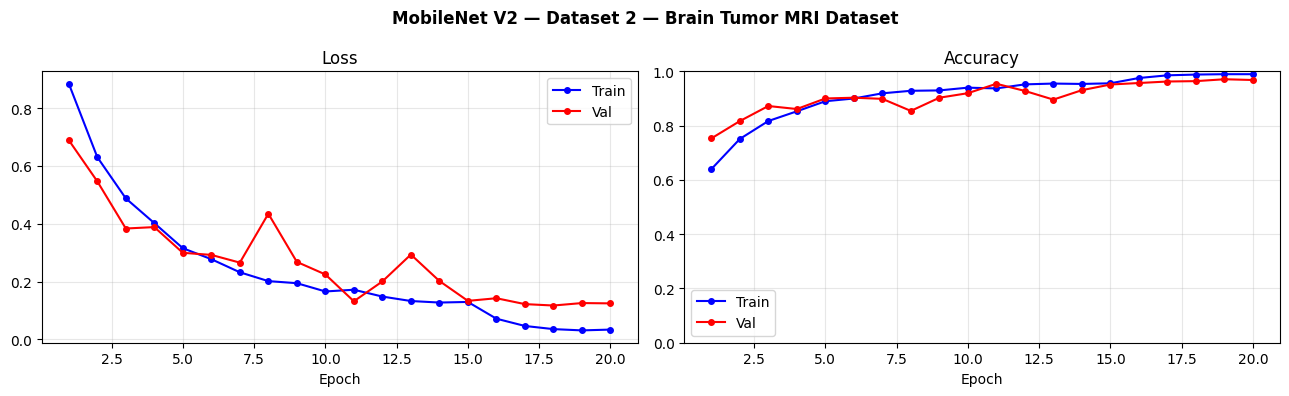

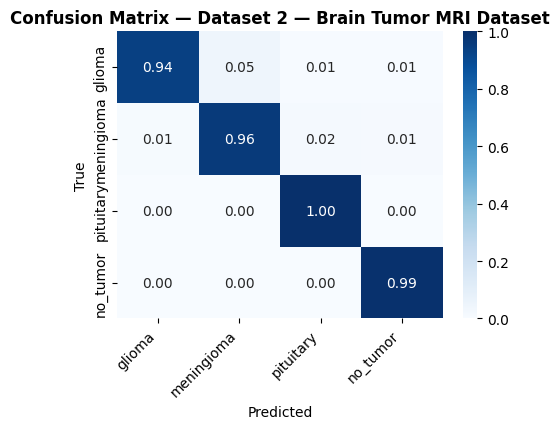

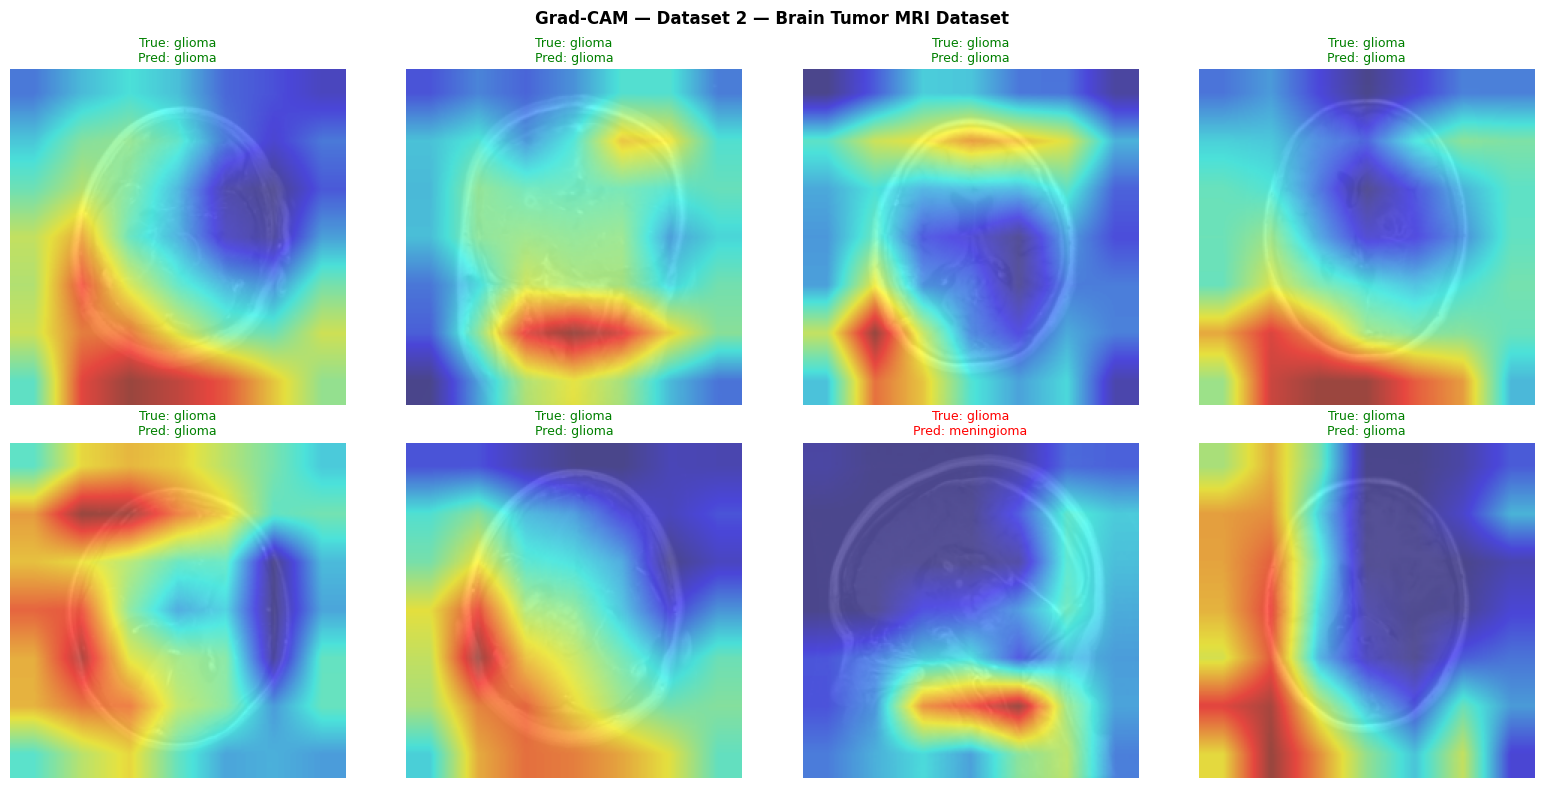


  Dataset 3/3: Dataset 3 — Brain Tumor MRI Images 44 Classes
  Classes: 44
Ep [ 1/20] Train 2.8814/0.2177 | Val 2.0663/0.3912 | 93.3s ✅
Ep [ 2/20] Train 1.4567/0.5726 | Val 1.5668/0.5394 | 91.8s ✅
Ep [ 3/20] Train 0.7764/0.7698 | Val 1.1383/0.6713 | 91.0s ✅
Ep [ 4/20] Train 0.4644/0.8605 | Val 0.9433/0.7407 | 91.2s ✅
Ep [ 5/20] Train 0.3214/0.9017 | Val 0.8017/0.7407 | 91.3s ✅
Ep [ 6/20] Train 0.2518/0.9233 | Val 0.6165/0.8148 | 92.5s ✅
Ep [ 7/20] Train 0.2129/0.9365 | Val 0.6849/0.8356 | 92.7s
Ep [ 8/20] Train 0.1763/0.9464 | Val 0.7154/0.8032 | 90.7s
Ep [ 9/20] Train 0.1854/0.9421 | Val 0.5250/0.8495 | 91.0s ✅
Ep [10/20] Train 0.1602/0.9501 | Val 0.6282/0.8380 | 91.0s
Ep [11/20] Train 0.1459/0.9540 | Val 0.5501/0.8356 | 93.0s
Ep [12/20] Train 0.1308/0.9612 | Val 0.6488/0.8356 | 92.5s
Ep [13/20] Train 0.1424/0.9567 | Val 0.6680/0.8264 | 92.1s
Ep [14/20] Train 0.0352/0.9903 | Val 0.3915/0.9005 | 92.0s ✅
Ep [15/20] Train 0.0161/0.9965 | Val 0.4051/0.8981 | 91.8s
Ep [16/20] Train 0.0128

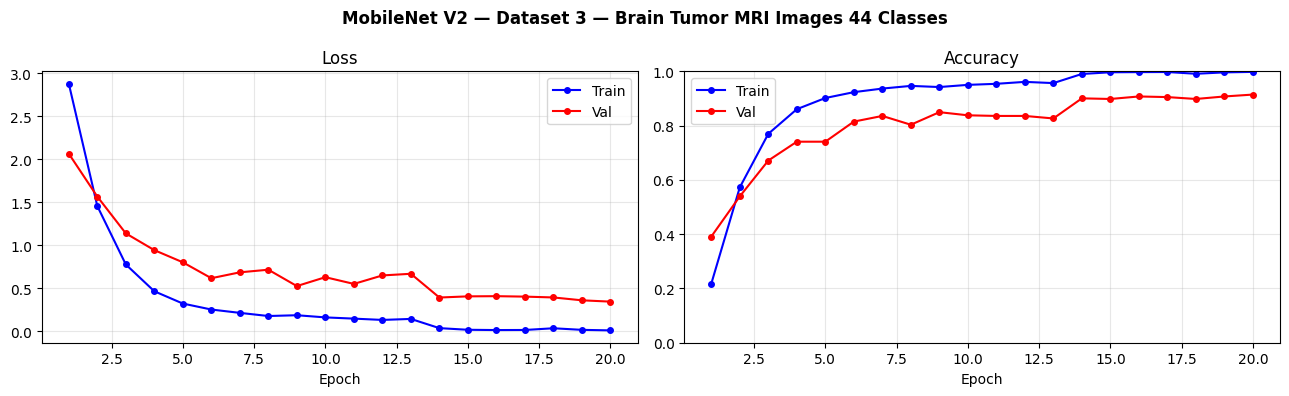

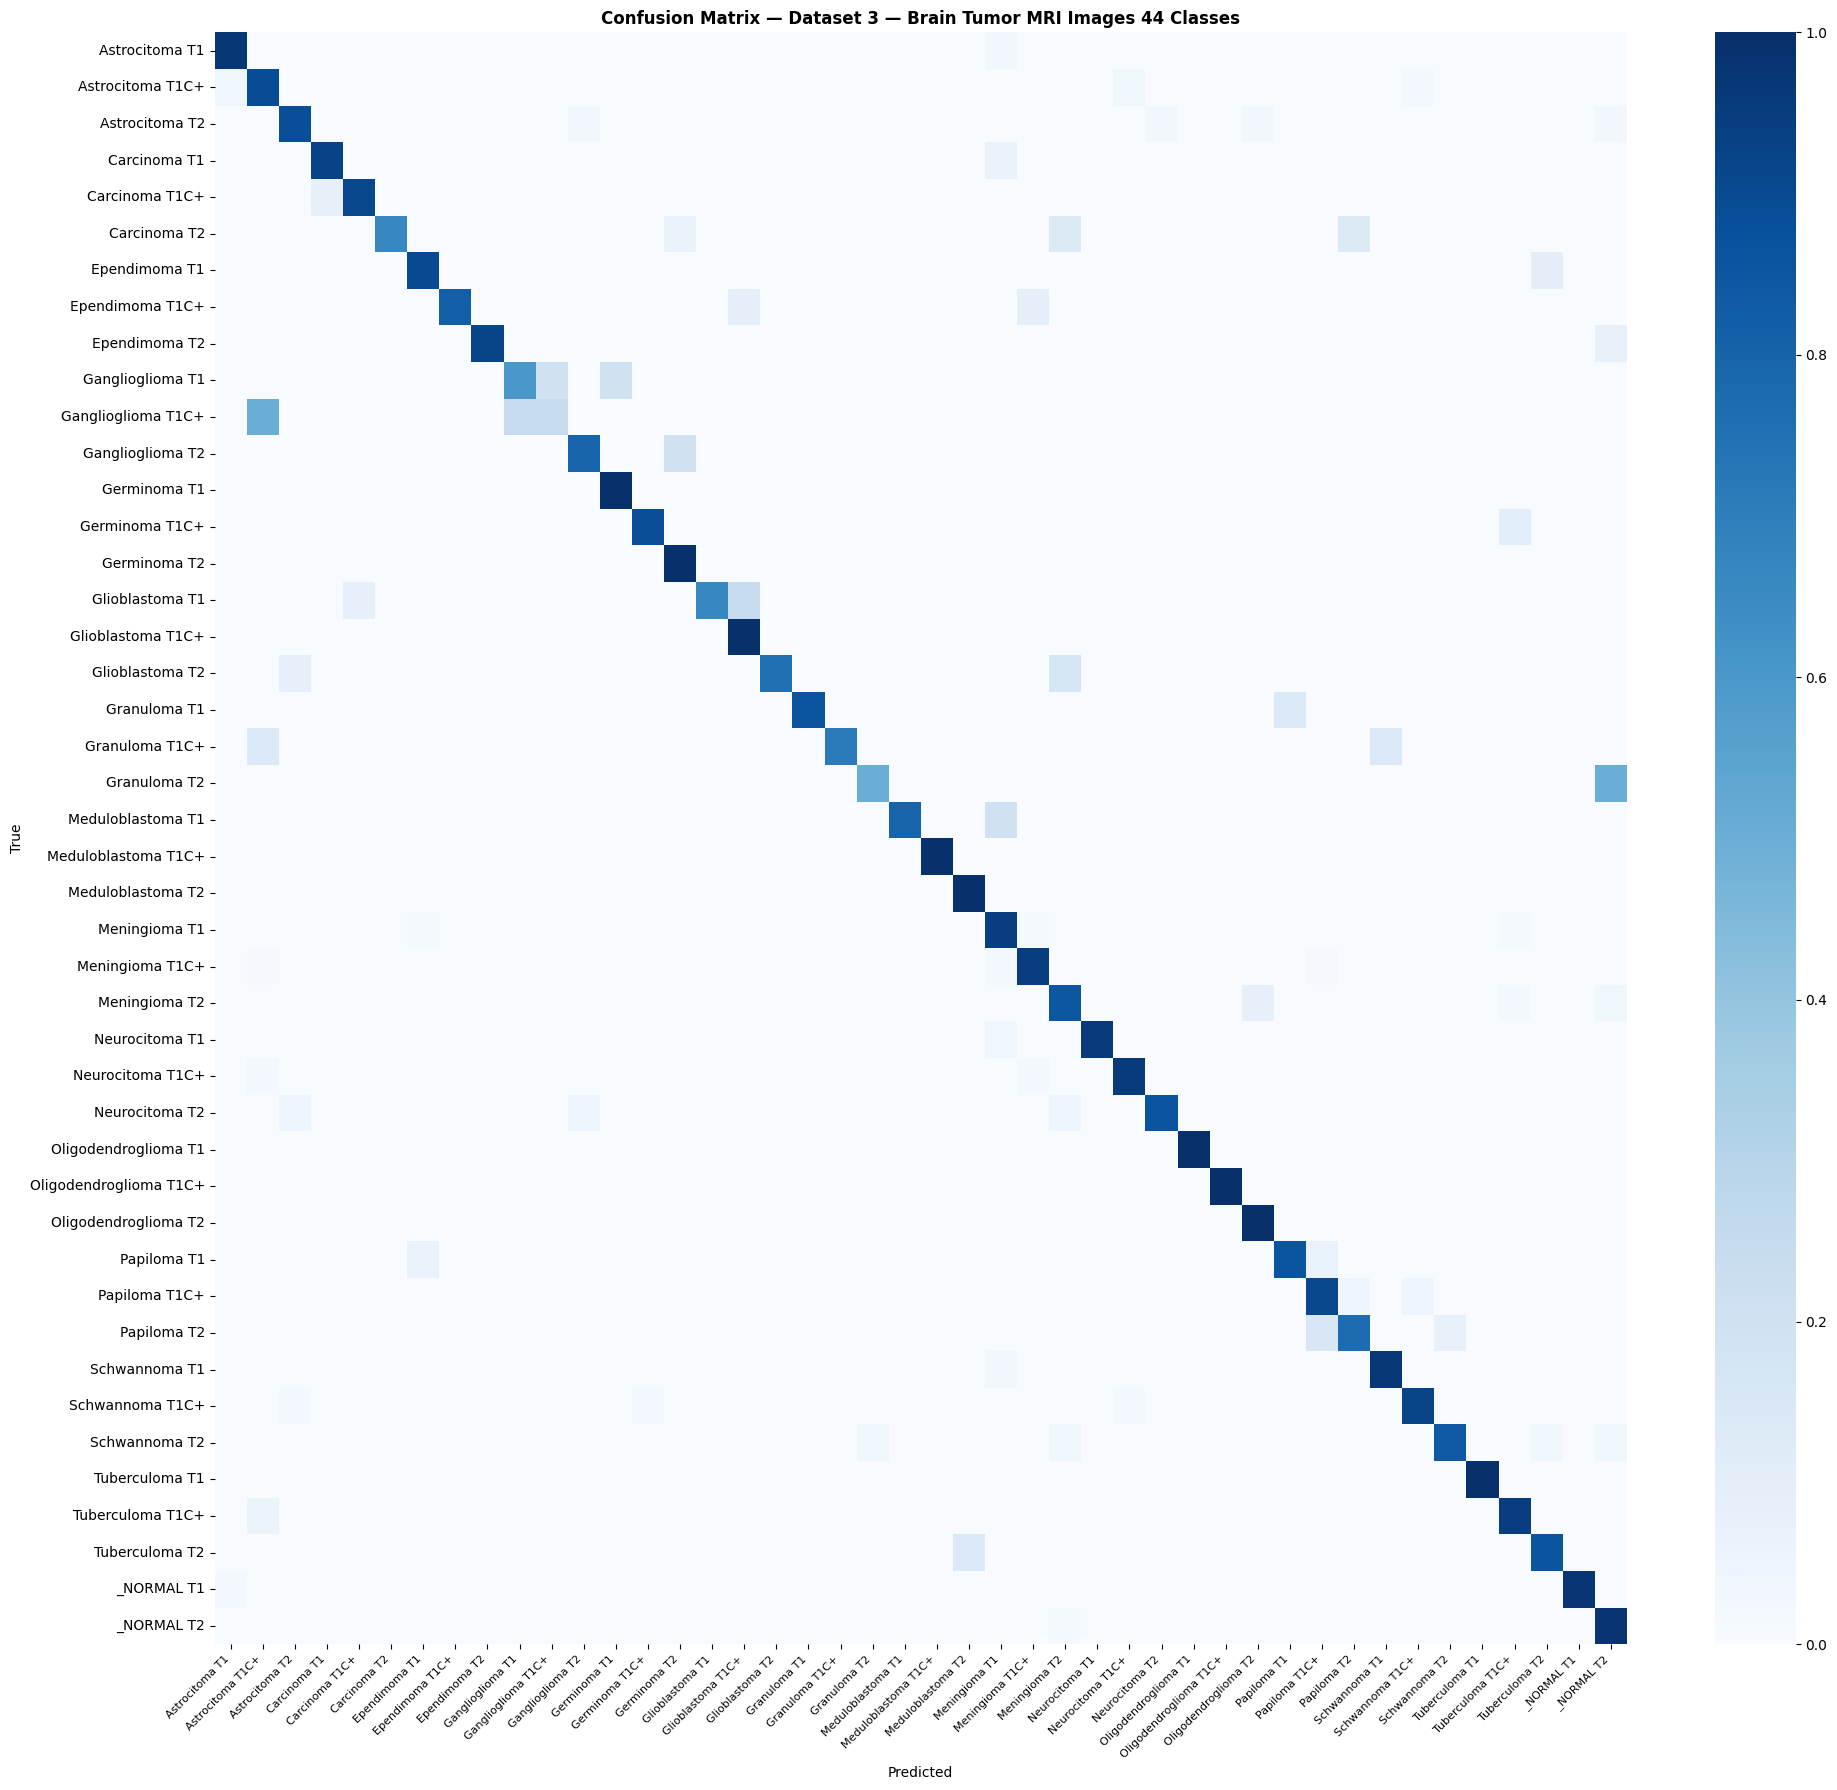

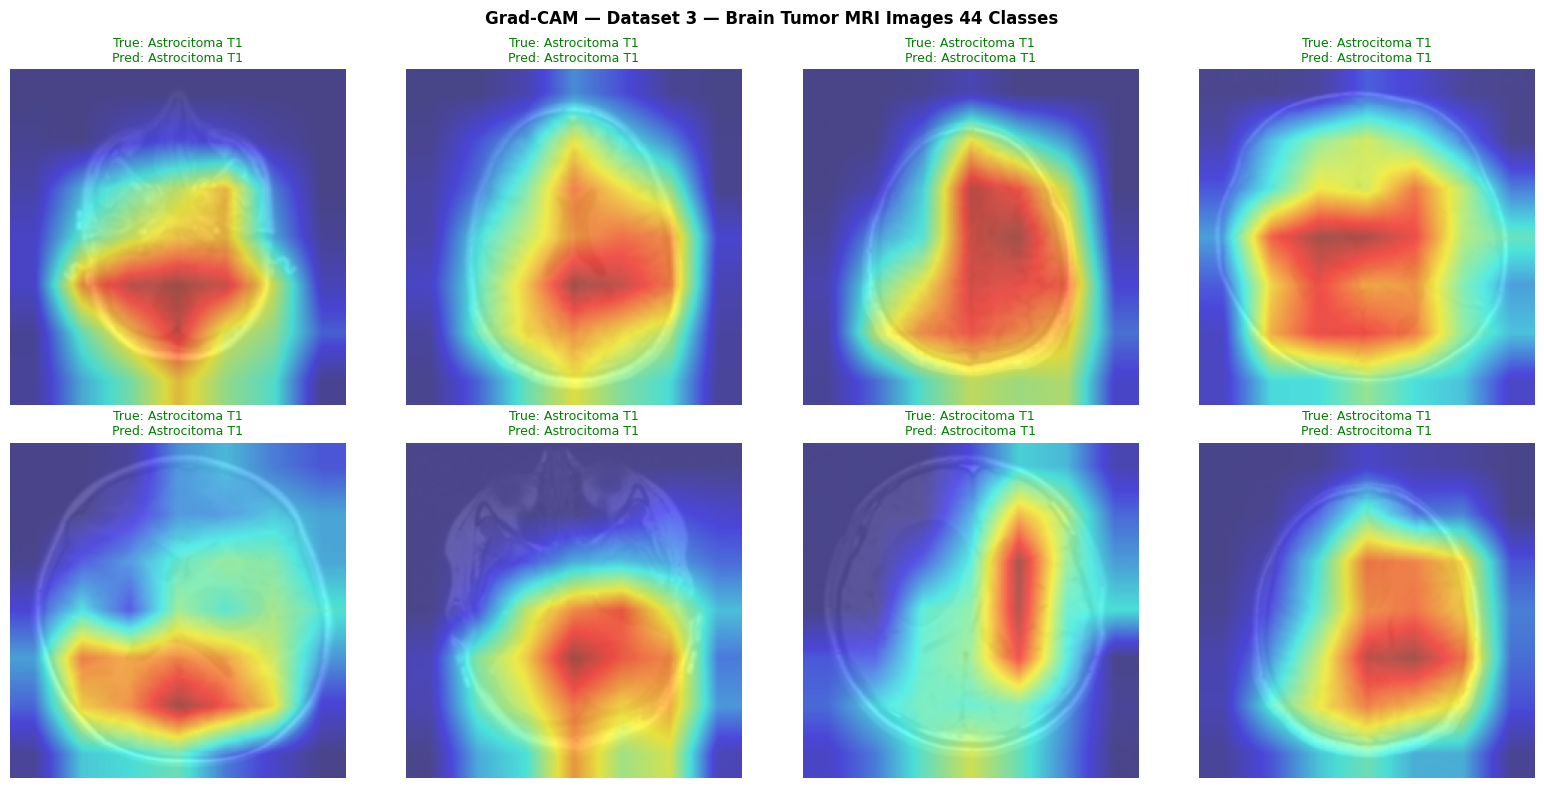


 All datasets complete!


In [13]:
all_results = {}

for i, cfg in enumerate(DATASETS, start=1):
    print(f'\n{"="*55}\n  Dataset {i}/3: {cfg["name"]}\n  Classes: {cfg["num_classes"]}\n{"="*55}')

    model    = build_mobilenet_v2(cfg['num_classes'])
    ckpt     = OUTPUT_DIR / f'mobilenet_v2_dataset{i}_best.pth'
    # train_model uses the updated train_one_epoch which handles grayscale inputs
    model, history = train_model(model, cfg, ckpt)

    print('\n── Test Results ──')
    results  = full_evaluation(model, cfg['test_loader'], cfg['num_classes'], cfg['class_names'])
    all_results[cfg['name']] = results

    print('\n── Plots ──')
    plot_curves(history, cfg['name'],           OUTPUT_DIR / f'mobilenet_v2_dataset{i}_curves.png')
    plot_confusion_matrix(results, cfg['class_names'], cfg['name'], OUTPUT_DIR / f'mobilenet_v2_dataset{i}_confusion.png')
    plot_grad_cam(model, cfg['test_loader'],    cfg['class_names'], cfg['name'], OUTPUT_DIR / f'mobilenet_v2_dataset{i}_gradcam.png')

    del model; torch.cuda.empty_cache()

print('\n All datasets complete!')

In [14]:
!pip install fpdf --quiet

  Preparing metadata (setup.py) ... done


In [15]:
from fpdf import FPDF
import datetime
from pathlib import Path
import os

# Ensure OUTPUT_DIR is defined
OUTPUT_DIR = Path('/content/drive/MyDrive/COMP472/outputs/mobilenet_v2')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

class PDFReport(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 15)
        self.cell(0, 10, 'MobileNet V2 - Brain Tumor Classification Report', 0, 1, 'C')
        self.ln(5)

    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.cell(0, 10, f'Page {self.page_no()}', 0, 0, 'C')

def create_report(all_results, output_path, output_dir):
    pdf = PDFReport()
    pdf.set_auto_page_break(auto=True, margin=15)

    # Title Page
    pdf.add_page()
    pdf.set_font('Arial', '', 12)
    pdf.cell(0, 10, f'Date: {datetime.date.today()}', 0, 1)
    pdf.ln(5)

    # 1. Hyperparameters Section
    pdf.set_font('Arial', 'B', 16)
    pdf.cell(0, 10, 'Global Hyperparameters', 0, 1)
    pdf.ln(2)
    pdf.set_font('Arial', '', 12)

    hparams = {
        'Batch Size': BATCH_SIZE if 'BATCH_SIZE' in globals() else 'N/A',
        'Epochs': NUM_EPOCHS if 'NUM_EPOCHS' in globals() else 'N/A',
        'Learning Rate': f"{LEARNING_RATE:.6f}" if 'LEARNING_RATE' in globals() else 'N/A',
        'Weight Decay': WEIGHT_DECAY if 'WEIGHT_DECAY' in globals() else 'N/A',
        'Image Size': f"{IMG_SIZE}x{IMG_SIZE}" if 'IMG_SIZE' in globals() else 'N/A'
    }

    for k, v in hparams.items():
        pdf.cell(0, 8, f"- {k}: {v}", 0, 1)

    pdf.ln(10)

    # 2. Dataset Specific Results
    for i, (name, r) in enumerate(all_results.items(), start=1):
        safe_name = name.replace('\u2014', '-')
        pdf.set_font('Arial', 'B', 16)
        pdf.cell(0, 10, f'Dataset {i}: {safe_name}', 0, 1)
        pdf.ln(5)

        # Metrics Table
        pdf.set_font('Arial', 'B', 12)
        pdf.cell(40, 10, 'Metric', 1)
        pdf.cell(40, 10, 'Value', 1, 1)

        pdf.set_font('Arial', '', 12)
        pdf.cell(40, 10, 'Accuracy', 1)
        pdf.cell(40, 10, f"{r['acc']:.4f}", 1, 1)
        pdf.cell(40, 10, 'Precision', 1)
        pdf.cell(40, 10, f"{r['prec']:.4f}", 1, 1)
        pdf.cell(40, 10, 'Recall', 1)
        pdf.cell(40, 10, f"{r['rec']:.4f}", 1, 1)
        pdf.cell(40, 10, 'F1-Score', 1)
        pdf.cell(40, 10, f"{r['f1']:.4f}", 1, 1)
        pdf.ln(10)

        # Embed Visualizations
        curve_path = str(output_dir / f'mobilenet_v2_dataset{i}_curves.png')
        if os.path.exists(curve_path):
            pdf.set_font('Arial', 'B', 12)
            pdf.cell(0, 10, 'Training & Validation Curves', 0, 1)
            pdf.image(curve_path, x=10, w=180)
            pdf.ln(5)

        cm_path = str(output_dir / f'mobilenet_v2_dataset{i}_confusion.png')
        if os.path.exists(cm_path):
            pdf.cell(0, 10, 'Confusion Matrix', 0, 1)
            pdf.image(cm_path, x=10, w=140)
            pdf.add_page()

        cam_path = str(output_dir / f'mobilenet_v2_dataset{i}_gradcam.png')
        if os.path.exists(cam_path):
            pdf.cell(0, 10, 'Grad-CAM Interpretability', 0, 1)
            pdf.image(cam_path, x=10, w=180)

        if i < len(all_results):
            pdf.add_page()

    pdf.output(output_path)
    print(f'Report with Hyperparameters saved to: {output_path}')

# Generate a unique filename
timestamp = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M')
report_path = str(OUTPUT_DIR / f'MobileNetV2_Report_{timestamp}.pdf')

try:
    create_report(all_results, report_path, OUTPUT_DIR)
except NameError as e:
    print(f"Error: {e}. Please ensure the training loop (Section 7) has finished to populate 'all_results'.")

Report with Hyperparameters saved to: /content/drive/MyDrive/COMP472/outputs/mobilenet_v2/MobileNetV2_Report_2026-04-05_16-35.pdf
